In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
import joblib

In [95]:
df= pd.read_csv('/content/dataset.csv', encoding= 'utf-8-sig')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [96]:
print('Rows and Columns:', df.shape)
print('Column List:',df.columns.tolist())


Rows and Columns: (4424, 35)
Column List: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [97]:
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [98]:
# Missing data and Duplicates
print('Missing Values:', df.isnull().sum().sum())
print('Duplicates:',df.duplicated().sum())

Missing Values: 0
Duplicates: 0


In [99]:
# Check the gender vs dropout pattern
# Gender 0= Female, Gender 1= Male
pd.crosstab(df['Gender'], df['Target'], normalize='index').round(3)*100

Target,Dropout,Enrolled,Graduate
Gender,,,
0,25.1,17.0,57.9
1,45.1,19.7,35.2


## Preparing Data for the Model

In [100]:
# Exact Target Labels
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [101]:
# Turn the text labels into the numbers
le = LabelEncoder()
df['Target_encoded']= le.fit_transform(df['Target'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [102]:
# Separate Clues from Answers
X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

In [103]:
# Split into a 'learning pile' and a 'testing plie'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )
print('Training rows:',X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 3539
Testing rows: 885


In [104]:
print(y_train.value_counts(normalize=True).round(3)*100)

Target_encoded
2    49.9
0    32.1
1    17.9
Name: proportion, dtype: float64


## First Working Model

In [105]:
model_balanced= LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [106]:
# Make Predictions on the hidden test students
predictions= model_balanced.predict(X_test)
print(predictions[:10])
print(y_test[:10].values)

[2 2 0 2 2 1 2 2 2 2]
[2 2 1 2 2 2 2 2 2 2]


In [107]:
# Check Overall accuracy
accuracy= accuracy_score(y_test, predictions)
print(f'Accuracy:{accuracy:.2%}')

Accuracy:74.01%


In [108]:
# Accuracy Broken down by outcome group
print(classification_report(y_test, predictions, target_names=['Droptout','Enrolled','Graduate']))

              precision    recall  f1-score   support

    Droptout       0.84      0.68      0.75       284
    Enrolled       0.43      0.65      0.52       159
    Graduate       0.87      0.81      0.84       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.78      0.74      0.75       885



In [109]:
# Random Forest
rf_model= RandomForestClassifier(n_estimators=200,class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions= rf_model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,rf_predictions))
print(classification_report(y_test, rf_predictions, target_names=['Dropout','Enrolled','Graduate']))

Accuracy: 0.7807909604519774
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.58      0.38      0.46       159
    Graduate       0.80      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.77       885



In [110]:
# XGBoost Model
sample_weights= compute_sample_weight(class_weight='balanced',y=y_train)
xgb_model= xgb.XGBClassifier(n_estimators=200,random_state=42,eval_metric='mlogloss')
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_predictions= xgb_model.predict(X_test)
print('Accuracy:', accuracy_score(y_test,xgb_predictions))
print(classification_report(y_test, xgb_predictions, target_names=['Dropout','Enrolled','Graduate']))

Accuracy: 0.7548022598870057
              precision    recall  f1-score   support

     Dropout       0.80      0.72      0.76       284
    Enrolled       0.48      0.47      0.48       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.69      0.69       885
weighted avg       0.75      0.75      0.75       885



In [111]:
# Compare Models side by side
results={'Logistic Regression(balanced)':accuracy_score(y_test, predictions), 'Random Forest':accuracy_score(y_test, rf_predictions), 'XGBoost': accuracy_score(y_test, xgb_predictions)}
for name, acc in sorted(results.items(), key=lambda item: -item[1]):
    print(f'{name}: {acc:.2%}')

Random Forest: 78.08%
XGBoost: 75.48%
Logistic Regression(balanced): 74.01%


In [74]:
# Install and import SHAP
!pip install shap
import shap

In [112]:
# Calculate Explanations
explainer= shap.Explainer(xgb_model)
shap_values= explainer(X_test)

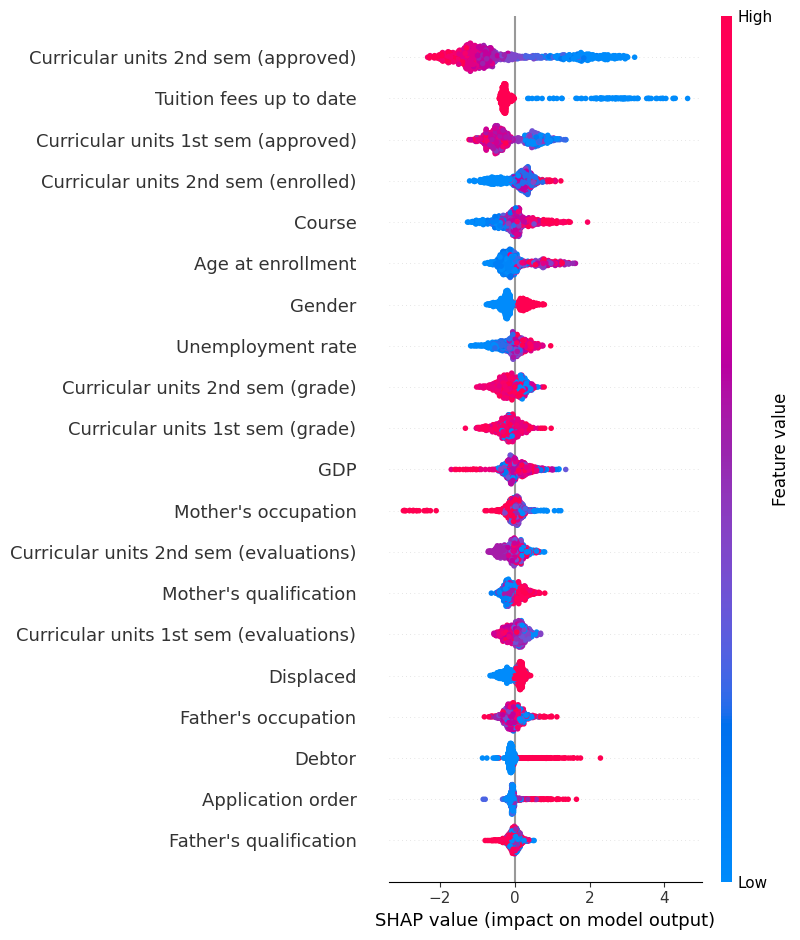

In [113]:
# Which Feature matters the most for predicting Dropout
shap.summary_plot(shap_values[:,:,0], X_test, show=True)

Male students in test set: 315
Female students in test set: 570


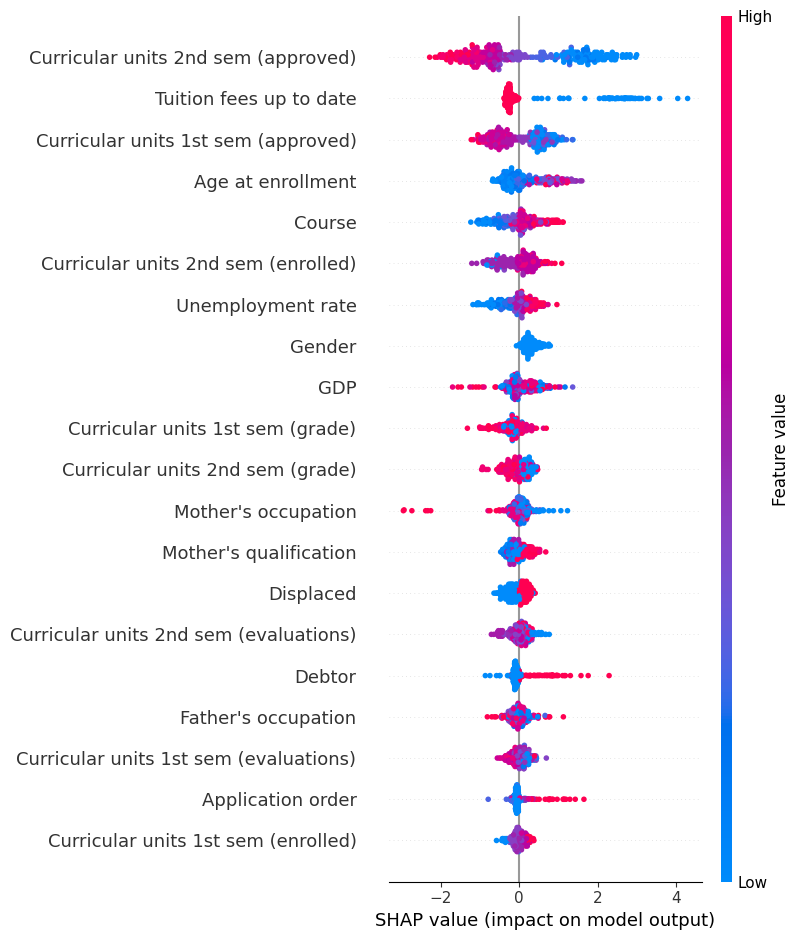

In [114]:
# For Male Students
X_test_male= X_test[X_test['Gender']==1]
X_test_female=X_test[X_test['Gender']==0]
shap_male=explainer(X_test_male)
shap_female=explainer(X_test_female)
print('Male students in test set:', len(X_test_male))
print('Female students in test set:',len(X_test_female))
shap.summary_plot(shap_male[:,:,0], X_test_male, show= True)

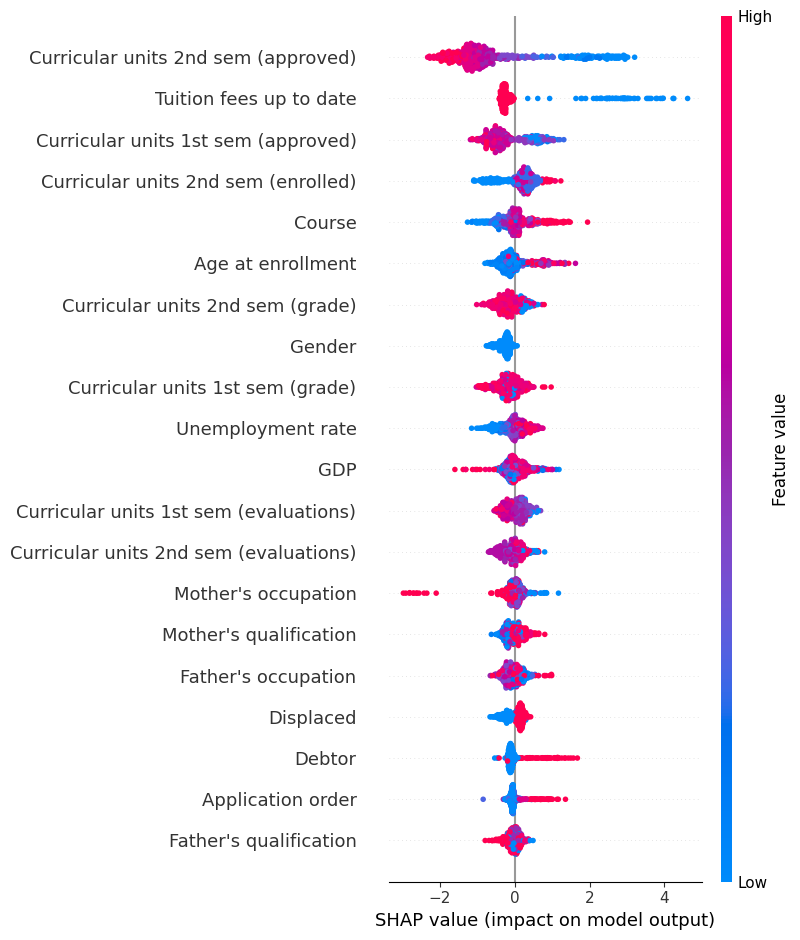

In [115]:
# Same chart for the female students
shap.summary_plot(shap_female[:,:,0], X_test_female, show= True)

### Interpretation: Gender and Dropout Risk

Using SHAP values, we examined which features most strongly influence the model's
dropout predictions, and specifically compared these drivers between male and
female students.

**Across all students**, the three strongest predictors of dropout risk are, in
order: number of curricular units approved in the 2nd semester, whether tuition
fees are up to date, and number of curricular units approved in the 1st semester.
This same ranking holds true when male and female students are analyzed
separately — academic performance and financial standing are the dominant
drivers of dropout risk for both genders.

Gender itself ranks moderately (around 7th-8th) in overall importance for both
groups, indicating it is a real but secondary factor rather than a primary driver.

**A closer look reveals two smaller gender-specific differences:**
- Age at enrollment ranks higher for male students, suggesting that older,
  non-traditional enrollment age is a stronger risk signal specifically among
  male students.
- Semester grades rank slightly higher for female students, suggesting grade
  performance is a marginally stronger predictor of outcome for female students
  compared to male students.

**Conclusion:** Although male students in this dataset drop out at nearly double
the rate of female students (45% vs 25%), this gap is not primarily explained by
gender-specific risk factors. Instead, both groups are driven by the same
underlying academic and financial pressures — these pressures simply appear to
affect male students more severely in this dataset. This suggests that
intervention strategies (tuition support, early academic monitoring) would
likely be effective across both genders, rather than requiring fundamentally
different approaches by gender.

In [116]:
# 12 most important features
important_features=['Curricular units 2nd sem (approved)', 'Tuition fees up to date', 'Curricular units 1st sem (approved)',
                    'Curricular units 2nd sem (enrolled)', 'Course', 'Age at enrollment', 'Gender', 'Unemployment rate', 'Curricular units 2nd sem (grade)',
                    'Curricular units 1st sem (grade)','Debtor', 'Scholarship holder']
X_simple= df[important_features]
y_simple= df['Target_encoded']

In [117]:
# Retrain a smaller model using just thise 12 features
X_train_s, X_test_s, y_train_s, y_test_s= train_test_split(X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple)
weight_s=compute_sample_weight(class_weight='balanced',y=y_train_s)
simple_model= xgb.XGBClassifier(n_estimators=200, random_State=42, eval_metric='mlogloss')
simple_model.fit(X_train_s,y_train_s, sample_weight=weight_s)
print('Simplified Model Accuracy:', accuracy_score(y_test_s, simple_model.predict(X_test_s)))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "random_State" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Simplified Model Accuracy: 0.7401129943502824


In [126]:
joblib.dump(simple_model, 'dropout_model.pkl')
print('Model saved!')
from google.colab import files
files.download('dropout_model.pkl')

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>